# Module 10 — NMVOC Oxidation I: Alkanes and Alkenes
### B4 Chemistry in the Atmosphere · companion notebook

Covers: alkane OH- vs Cl-oxidation lifetimes, Example 4 (2-pentoxy radical fate), the
"3 O3 per -CH2-" rule of thumb, and a simple RO2 fate calculator.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

## Alkane lifetimes: OH vs Cl oxidation

$$\tau_X = \frac{1}{k_X [X]}$$

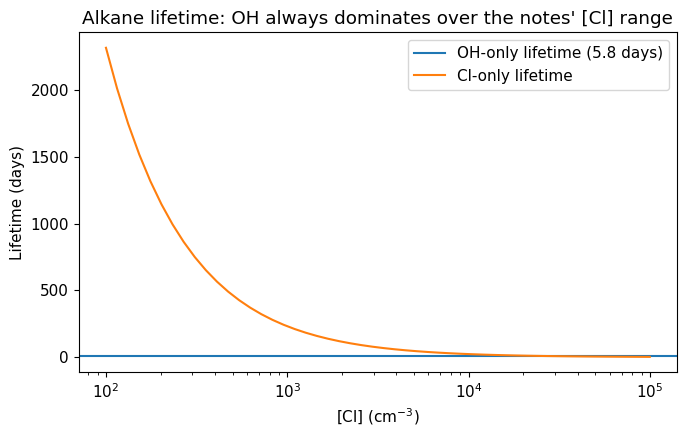

Combined OH+Cl lifetime at [Cl]=1e5: 1.65 days vs OH-only 5.79 days
-> Cl makes a negligible difference to the overall alkane lifetime, as the notes state.


In [2]:
k_OH_alkane = 2e-12    # cm^3/s, representative mid-range value
k_Cl_alkane = 5e-11    # cm^3/s, representative

OH_conc = 1e6           # cm^-3, typical daytime average
Cl_range = np.logspace(2, 5, 50)   # cm^-3, notes' quoted range of uncertainty

tau_OH_days = 1/(k_OH_alkane*OH_conc)/86400
tau_Cl_days = 1/(k_Cl_alkane*Cl_range)/86400

plt.figure()
plt.axhline(tau_OH_days, color='C0', label=f'OH-only lifetime ({tau_OH_days:.1f} days)')
plt.semilogx(Cl_range, tau_Cl_days, color='C1', label='Cl-only lifetime')
plt.xlabel('[Cl] (cm$^{-3}$)')
plt.ylabel('Lifetime (days)')
plt.legend()
plt.title('Alkane lifetime: OH always dominates over the notes\' [Cl] range')
plt.tight_layout()
plt.show()

# Combined lifetime at the high end of the Cl range
tau_combined = 1/(k_OH_alkane*OH_conc + k_Cl_alkane*Cl_range[-1])/86400
print(f"Combined OH+Cl lifetime at [Cl]=1e5: {tau_combined:.2f} days vs OH-only {tau_OH_days:.2f} days")
print("-> Cl makes a negligible difference to the overall alkane lifetime, as the notes state.")

## Example 4 — fate of the 2-pentoxy radical

RO has three competing channels: reaction with O2, isomerization (6-membered TS, needs >4 C),
and decomposition. We compare pseudo-first-order rates for illustrative rate constants.

In [3]:
k_O2 = 8e-15          # cm^3/s, RO + O2 -> carbonyl + HO2 (rate constant)
O2_conc = 0.21 * 2.5e19  # cm^-3

k_isom = 1e5          # s^-1, unimolecular isomerization rate (illustrative, 2-pentoxy CAN isomerize: 5 carbons)
k_decomp = 1e4         # s^-1, unimolecular decomposition rate (illustrative)

rate_O2 = k_O2 * O2_conc
rate_isom = k_isom
rate_decomp = k_decomp

rates = {'O2 addition': rate_O2, 'Isomerization': rate_isom, 'Decomposition': rate_decomp}
total = sum(rates.values())

print(f"{'Channel':20s}{'Rate (s^-1)':>15s}{'Branching %':>15s}")
for name, r in rates.items():
    print(f"{name:20s}{r:15.2e}{100*r/total:14.1f}%")

Channel                 Rate (s^-1)    Branching %
O2 addition                4.20e+04          27.6%
Isomerization              1.00e+05          65.8%
Decomposition              1.00e+04           6.6%


2-pentoxy has 5 carbons, so isomerization via a 6-membered transition state IS geometrically
possible (the notes note this channel only opens up for >4 carbon compounds) -- consistent with
isomerization being competitive here, as opposed to a shorter alkoxy radical where only the O2
and decomposition channels would be available.

## The "3 O3 per -CH2- group" rule of thumb

Ethane (C2H6) oxidation to completion, in the presence of NO, is said to yield around double the
O3 of methane oxidation. We tabulate the naive maximum O3 yield (3 per -CH2- group oxidised) for
a few simple alkanes.

In [4]:
alkanes = {
    'CH4 (methane)': 0,     # no -CH2- groups; special case, ~1 O3 max per full oxidation to CO2
    'C2H6 (ethane)': 1,     # 1 -CH2--equivalent step beyond methane's oxidation number
    'C3H8 (propane)': 2,
    'C4H10 (butane)': 3,
}

print(f"{'Alkane':20s}{'Max O3 yield (illustrative)':>30s}")
for name, n_ch2 in alkanes.items():
    max_O3 = 1 + 3*n_ch2 if name != 'CH4 (methane)' else 1
    print(f"{name:20s}{max_O3:30d}")

print("\nNote: this is a simple bookkeeping heuristic from the notes ('max 3 O3 per -CH2-")
print("group'), not a rigorous mechanistic yield -- real yields depend heavily on NOx regime,")
print("branching ratios, and how far oxidation proceeds before termination/deposition.")

Alkane                 Max O3 yield (illustrative)
CH4 (methane)                                    1
C2H6 (ethane)                                    4
C3H8 (propane)                                   7
C4H10 (butane)                                  10

Note: this is a simple bookkeeping heuristic from the notes ('max 3 O3 per -CH2-
group'), not a rigorous mechanistic yield -- real yields depend heavily on NOx regime,
branching ratios, and how far oxidation proceeds before termination/deposition.


## A simple RO2 fate calculator

Rank RO2 loss pathways (R4.2-R4.8) for polluted vs remote-marine [NO] regimes.

In [5]:
def RO2_fate(NO, HO2=1e8, RO2_other=1e7, NO3=1e7):
    k_42 = 9e-12   # RO2+NO -> RO+NO2
    k_44 = 6e-12   # RO2+HO2 -> ROOH+O2
    k_45 = 1e-13   # RO2+RO2 (representative overall)
    k_48 = 2.3e-12 # RO2+NO3 -> RO+NO2+O2

    rates = {
        'RO2+NO (R4.2)': k_42*NO,
        'RO2+HO2 (R4.4)': k_44*HO2,
        'RO2+RO2 (R4.5-7)': k_45*RO2_other,
        'RO2+NO3 (R4.8)': k_48*NO3,
    }
    return rates

M = 2.5e19
scenarios = {
    'Polluted (NO=1 ppb)': M*1e-9,
    'Remote marine (NO=10 ppt)': M*1e-11,
}

for name, NO_conc in scenarios.items():
    print(f"\n{name}:")
    rates = RO2_fate(NO_conc)
    total = sum(rates.values())
    for k, v in rates.items():
        print(f"  {k:20s}{100*v/total:6.1f}%")


Polluted (NO=1 ppb):
  RO2+NO (R4.2)         99.7%
  RO2+HO2 (R4.4)         0.3%
  RO2+RO2 (R4.5-7)       0.0%
  RO2+NO3 (R4.8)         0.0%

Remote marine (NO=10 ppt):
  RO2+NO (R4.2)         78.3%
  RO2+HO2 (R4.4)        20.9%
  RO2+RO2 (R4.5-7)       0.0%
  RO2+NO3 (R4.8)         0.8%


## Exercises

1. **Full RO2 fate vs [NO].** Plot the branching percentages from `RO2_fate` as a function of
   [NO] spanning the polluted-to-remote range, and identify the crossover [NO] where RO2+NO stops
   dominating.

2. **Isomerization threshold.** The notes state isomerization needs >4 carbons for a 6-membered
   TS. For a butoxy radical (4 carbons, right at the boundary), how would you expect `k_isom` to
   compare to the 2-pentoxy value used above? Adjust the toy rate constants to reflect a much
   less favourable (or impossible) isomerization geometry and see how the branching changes.

3. **O3 yield vs NOx regime.** The "3 O3 per -CH2-" rule assumes NO is always available to convert
   RO2 -> RO2+NO -> ... -> O3. Using your Module 8/9 RO2-fate machinery, argue qualitatively how
   the *realised* O3 yield per NMVOC molecule would fall short of this maximum in a low-NOx
   (remote marine) environment, where RO2+HO2 (chain-terminating) competes more effectively.